In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yasasashinsana","key":"6b8e9a4ec477707b1400d364996ac4a8"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c dogs-vs-cats
!unzip -q dogs-vs-cats.zip
!unzip -q train.zip

100% 812M/812M [00:23<00:00, 35.6MB/s]



In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "/content/train" # Unzip  dataset  path

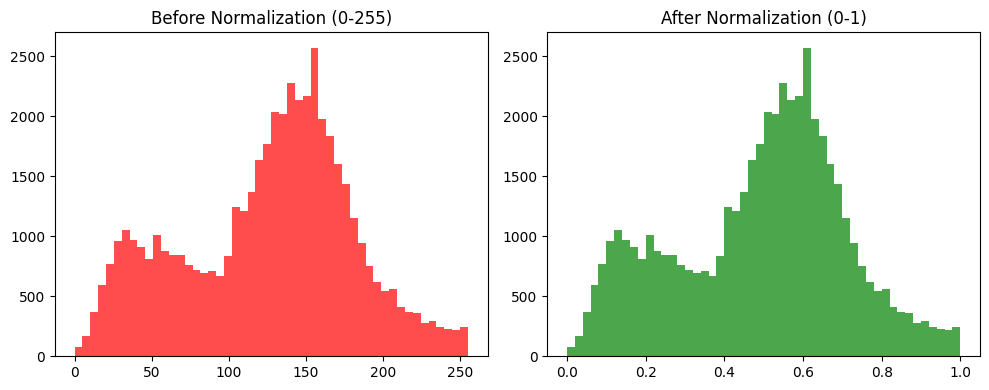

In [7]:
import os

# --- Member 4: Pixel Normalization ---
# X_train_resized array
# get a sample image

# Get a list of all files in the dataset_path directory
all_image_files = os.listdir(dataset_path)

# Filter for actual image files (assuming common image extensions)
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
image_paths = [os.path.join(dataset_path, f) for f in all_image_files if f.lower().endswith(image_extensions)]

# Check if any images were found
if not image_paths:
    raise FileNotFoundError(f"No image files found in the directory: {dataset_path}")

# Read the first image found
sample_img = cv2.imread(image_paths[0])

# Check if the image was loaded successfully
if sample_img is None:
    raise IOError(f"Could not load image from path: {image_paths[0]}")

sample_img = cv2.resize(sample_img, (128, 128))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# Normalization (Divide by 255.0)
normalized_img = sample_img / 255.0

# EDA Visualization: Histogram of Pixel Intensities
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(sample_img.ravel(), bins=50, color='red', alpha=0.7)
plt.title('Before Normalization (0-255)')

plt.subplot(1, 2, 2)
plt.hist(normalized_img.ravel(), bins=50, color='green', alpha=0.7)
plt.title('After Normalization (0-1)')

plt.tight_layout()
plt.show()